# MinMax Threshold Experiments
Charts for MinMaxCache threshold tuning and long-running comparison.

In [13]:
from chart_utils import *

## Threshold Sweep

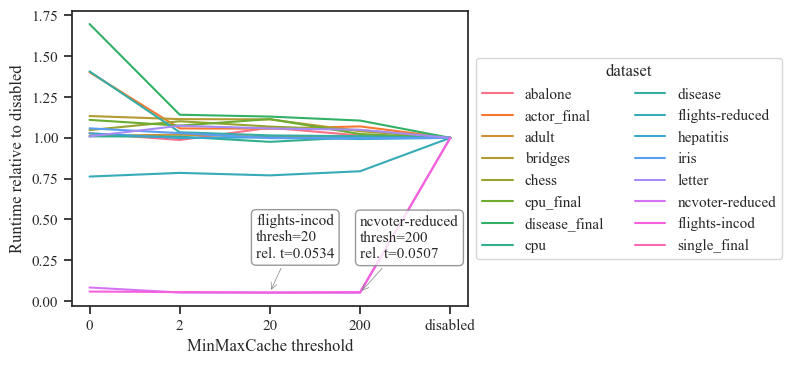

In [18]:
df_minmax = read_benchmark_metrics(
    str(benchmark_data_path / 'dynsbod_results/minmax_threshold/benchmark_metrics.json')
)
graph_data = (
    df_minmax
    .groupby(["algo_version", "dataset"])
    .aggregate({"max_mem_mb": "mean", "total_ms": "mean"})
    .reset_index()
)

algo_threshold_mapping = {
    str(i): v
    for i, v in enumerate(("0", "2", "5", "10", "20", "50", "100", "200", "500", "disabled"))
}
graph_data["threshold"] = graph_data["algo_version"].replace(algo_threshold_mapping)
graph_data = graph_data[graph_data["threshold"].isin(["0", "2", "20", "200", "disabled"])]
graph_data_full = graph_data.copy()
graph_data = graph_data[~graph_data["dataset"].str.contains('baseline')]
graph_data["dataset"] = graph_data["dataset"].replace(
    "samples_flights_20_500k_0_390000", "flights-incod"
)
# the next two commands cause an error
graph_data["dataset"] = graph_data["dataset"].str.replace(
    "_final_state", "_final"
)
# graph_data["dataset"] = graph_data["dataset"].str.replace(
#     "_events_with_updates", ""
# )
graph_data = graph_data.drop_duplicates(subset=["dataset", "threshold"], keep="first")
graph_data = graph_data[~graph_data["dataset"].str.contains('samples')]
graph_data = graph_data[~graph_data["dataset"].str.contains('_events_with_updates')]
graph_data['dataset'] = graph_data['dataset'].str.replace('dynfd_', '')

# Make runtimes relative by dividing by the runtime when threshold is disabled
baseline_runtimes = (
    graph_data[graph_data["threshold"] == 'disabled']
    .set_index("dataset")["total_ms"]
)
datasets_without_known_baseline = set(graph_data["dataset"]) - set(baseline_runtimes.index)
graph_data = graph_data[graph_data["dataset"].isin(baseline_runtimes.index)]
graph_data["relative_runtime"] = graph_data.apply(
    lambda row: row["total_ms"] / baseline_runtimes[row["dataset"]], axis=1
)

include_all_datasets = False

ax = sns.lineplot(graph_data, x='threshold', y='relative_runtime', hue="dataset")
ax.set_ylabel("Runtime relative to disabled")
ax.set_xlabel("MinMaxCache threshold")

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5), ncols=2)

# Annotations for specific datasets
datasets_to_annotate = [('ncvoter-reduced', 0, '200', 3), ('flights-incod', -10, '20', 2)]
for dataset, xpos, threshold, index in datasets_to_annotate:
    data_point = graph_data[
        (graph_data['dataset'] == dataset) & (graph_data['threshold'] == threshold)
    ]
    if not data_point.empty:
        relative_runtime = data_point['relative_runtime'].values[0]
        ax.annotate(
            f'{dataset}\nthresh={threshold}\nrel. t={relative_runtime:.4f}',
            xy=(index, relative_runtime),
            xytext=(xpos, 25),
            textcoords='offset points',
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='gray', lw=0.5),
        )

save_figure("minmax", scaling=0.8)
plt.show()

In [15]:
graph_data.sort_values("relative_runtime")

,algo_version,dataset,max_mem_mb,total_ms,threshold,relative_runtime
242,4,ncvoter-reduced,21510.000000,625980.666667,20,0.050569
403,7,ncvoter-reduced,21509.000000,627944.333333,200,0.050727
77,1,ncvoter-reduced,21508.666667,647110.000000,2,0.052276
260,4,flights-incod,3151.000000,12183.000000,20,0.053352
95,1,flights-incod,3458.000000,12545.000000,2,0.054937
...,...,...,...,...,...,...
58,0,single_final_state,NaN,NaN,0,NaN
117,1,single_final_state,NaN,NaN,2,NaN
281,4,single_final_state,NaN,NaN,20,NaN
442,7,single_final_state,NaN,NaN,200,NaN


## MinMaxCache Long Experiment Comparison

In [16]:
minmax_long_dir = benchmark_data_path / "dynsbod_results/minmaxcache_long"
intermediate_dir = benchmark_data_path / "dynsbod_results/intermediate"

comparison_data = []

for stdout_file in minmax_long_dir.glob("*_stdout.txt"):
    dataset_name = stdout_file.stem.replace('algo0_java0_', '').replace('_run1_stdout', '')
    current_ops, total_ops, disabled_time = parse_progress_from_stdout(stdout_file)

    if current_ops is None or disabled_time is None:
        continue

    enabled_intermediate = intermediate_dir / f"algo0_java0_{dataset_name}_run1_stdout.intermediate.csv"
    enabled_time = None
    if enabled_intermediate.exists():
        enabled_time = get_time_at_operation(enabled_intermediate, current_ops)

    if enabled_time is not None:
        speedup = disabled_time / enabled_time
        comparison_data.append({
            'Dataset': dataset_name,
            'Insertions in 1h \\textbackslash w MMC': current_ops,
            'Time \\textbackslash wo MMC': int(enabled_time),
            'speedup': f"{speedup:.2f}x",
        })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)

    print("\n\nMinMaxCache Long Experiment Comparison:")
    print("=" * 80)
    print("Time to reach the same operation count where 'disabled' hit time limit")
    print("=" * 80)
    print(comparison_df.to_string(index=False))

    latex_comparison_df = comparison_df.copy()
    latex_comparison_df['Dataset'] = latex_comparison_df['Dataset'].apply(lambda x: x.split('_')[0])

    latex_table_output = latex_comparison_df.to_latex(
        index=False, escape=False,
        column_format='l' + 'r' * (len(latex_comparison_df.columns) - 1)
    )

    print("\nLaTeX Table:")
    print(latex_table_output)

    with open(thesis_charts_path / 'minmaxcache_long_comparison.tex', 'w') as f:
        f.write(latex_table_output)

    print(f"\nTable saved to: {thesis_charts_path / 'minmaxcache_long_comparison.tex'}")
else:
    print("No comparison data available")

datasets_without_known_baseline



MinMaxCache Long Experiment Comparison:
Time to reach the same operation count where 'disabled' hit time limit
           Dataset  Insertions in 1h \textbackslash w MMC  Time \textbackslash wo MMC speedup
             horse                                    300                         470   0.99x
   flights_20_500k                                 398330                        2015   1.78x
         plista_1k                                    625                        3698   0.97x
     fd-reduced-30                                 112059                        3688   0.98x
ncvoter_22_1m_utf8                                 213000                        2686   1.34x

LaTeX Table:
\begin{tabular}{lrrr}
\toprule
Dataset & Insertions in 1h \textbackslash w MMC & Time \textbackslash wo MMC & speedup \\
\midrule
horse & 300 & 470 & 0.99x \\
flights & 398330 & 2015 & 1.78x \\
plista & 625 & 3698 & 0.97x \\
fd-reduced-30 & 112059 & 3688 & 0.98x \\
ncvoter & 213000 & 2686 & 1.34x \\
\bottomr

set()